# Seleção de Features - Dataset DoS

Este notebook implementa **três métodos de seleção de features** para o dataset DoS:

1. **mRMR** (Minimum Redundancy Maximum Relevance): maximiza relevância e minimiza redundância
2. **Fisher's Score**: mede a capacidade discriminativa entre classes
3. **Correlação de Pearson**: mede a relação linear com o target

Ao final, comparamos os resultados dos três métodos.

## 1. Instalação e Importação de Bibliotecas

In [1]:
# Instalar mrmr-selection se não estiver instalado
# !pip install mrmr-selection

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
import warnings

# Seleção de features mRMR
try:
    from mrmr import mrmr_classif
    MRMR_AVAILABLE = True
except ImportError:
    MRMR_AVAILABLE = False
    print("⚠️ mRMR não está instalado. Instale com: pip install mrmr-selection")

# Sklearn
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score

warnings.filterwarnings('ignore')
plt.style.use('seaborn-v0_8-whitegrid')
pd.set_option('display.max_columns', None)

print("✅ Bibliotecas carregadas com sucesso!")

✅ Bibliotecas carregadas com sucesso!


## 2. Carregar e Preparar o Dataset DoS

In [6]:
# Carregar o dataset DoS
dos_path = Path("../data/raw/MQTT Under Attack Dataset/DoS.csv")
df = pd.read_csv(dos_path)

print(f"📊 Shape do dataset: {df.shape}")
print(f"📝 Colunas: {df.shape[1]}")
print(f"📋 Registros: {df.shape[0]}")
print(f"\n🏷️ Distribuição do Label ('type'):")
print(df['type'].value_counts())

📊 Shape do dataset: (94625, 67)
📝 Colunas: 67
📋 Registros: 94625

🏷️ Distribuição do Label ('type'):
type
normal    49111
DoS       45514
Name: count, dtype: int64


In [7]:
# Selecionar apenas features numéricas
num_df = df.select_dtypes(include=['int64', 'float64'])

# Colunas a remover (irrelevantes para detecção de ataques)
colunas_para_remover = [
    'frame.time_delta_displayed', 'frame.time_epoch', 'frame.time_invalid', 
    'frame.time_relative', 'tcp.srcport', 'tcp.dstport', 
    'frame.coloring_rule.name', 'frame.coloring_rule.string', 
    'frame.comment', 'frame.comment.expert', 'frame.encap_type', 
    'frame.file_off', 'frame.ignored', 'frame.incomplete', 
    'frame.interface_id', 'frame.interface_name', 'frame.link_nr', 
    'frame.marked', 'frame.md5_hash', 'frame.number', 'frame.offset_shift',
    'mqtt.msgid', 'mqtt.username', 'mqtt.passwd', 
    'mqtt.willmsg', 'mqtt.willtopic'
]

# Remover colunas existentes no dataframe
colunas_existentes = [c for c in colunas_para_remover if c in num_df.columns]
X = num_df.drop(columns=colunas_existentes, errors='ignore')

# Tratar valores ausentes e infinitos
X = X.fillna(0)
X = X.replace([np.inf, -np.inf], 0)

# Encode do label (target)
le = LabelEncoder()
y = le.fit_transform(df['type'])

print(f"✅ Features numéricas após limpeza: {X.shape[1]}")
print(f"🎯 Classes: {le.classes_}")
print(f"📊 Shape X: {X.shape}, y: {y.shape}")

✅ Features numéricas após limpeza: 29
🎯 Classes: ['DoS' 'normal']
📊 Shape X: (94625, 29), y: (94625,)


## 3. Seleção de Features via mRMR

O **mRMR (Minimum Redundancy Maximum Relevance)** seleciona features que:
1. **Máxima Relevância**: São fortemente relacionadas ao target (classificação)
2. **Mínima Redundância**: São minimamente redundantes entre si

Isso resulta em um subconjunto ótimo de features para modelagem.

In [8]:
# Aplicar mRMR para selecionar as top K features
if MRMR_AVAILABLE:
    K = 15  # Número de features a selecionar
    
    # Preparar dados para mRMR (precisa ser discretizado para classificação)
    # mRMR aceita X como DataFrame e y como Series
    X_mrmr = X.copy()
    y_series = pd.Series(y, name='target')
    
    print(f"🔍 Executando mRMR para selecionar {K} features...")
    
    # mRMR retorna lista de features selecionadas em ordem de importância
    selected_features = mrmr_classif(X=X_mrmr, y=y_series, K=K)
    
    print(f"\n🏆 Top {K} Features selecionadas por mRMR:")
    for i, feature in enumerate(selected_features, 1):
        print(f"  {i:2d}. {feature}")
else:
    print("⚠️ Instale mRMR com: pip install mrmr-selection")
    selected_features = None

🔍 Executando mRMR para selecionar 15 features...


100%|██████████| 15/15 [00:02<00:00,  5.93it/s]


🏆 Top 15 Features selecionadas por mRMR:
   1. mqtt.len
   2. mqtt.dupflag
   3. mqtt.msgtype
   4. mqtt.kalive
   5. frame.cap_len
   6. frame.len
   7. mqtt.topic_len
   8. frame.time_delta
   9. mqtt.qos
  10. mqtt.clientid_len
  11. mqtt.retain
  12. mqtt.conack.flags.reserved
  13. mqtt.conflag.cleansess
  14. mqtt.conack.val
  15. mqtt.proto_len


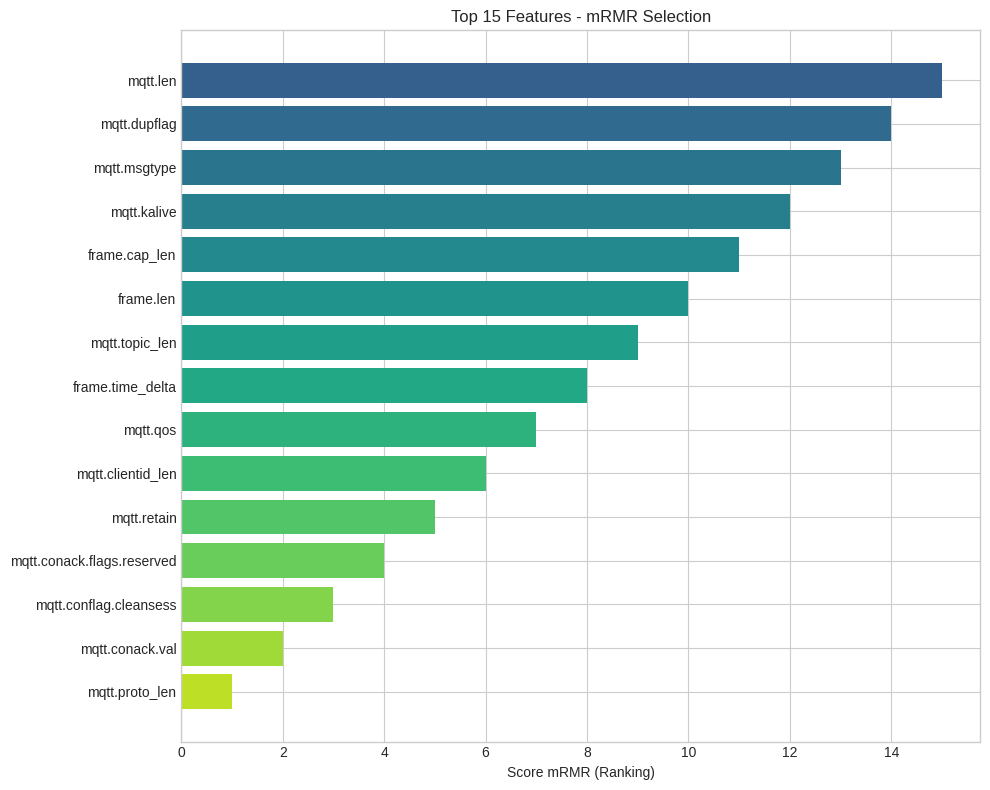

In [9]:
# Visualizar features selecionadas pelo mRMR
if selected_features:
    # Criar DataFrame com ranking
    mrmr_ranking = pd.DataFrame({
        'rank': range(1, len(selected_features) + 1),
        'feature': selected_features
    })
    
    # Plotar ranking
    fig, ax = plt.subplots(figsize=(10, 8))
    colors = plt.cm.viridis(np.linspace(0.3, 0.9, len(selected_features)))
    
    bars = ax.barh(range(len(selected_features)), 
                   range(len(selected_features), 0, -1),
                   color=colors)
    
    ax.set_yticks(range(len(selected_features)))
    ax.set_yticklabels(selected_features)
    ax.set_xlabel('Score mRMR (Ranking)')
    ax.set_title(f'Top {len(selected_features)} Features - mRMR Selection', fontsize=12)
    ax.invert_yaxis()
    
    plt.tight_layout()
    plt.show()

## 5. Seleção de Features via Fisher's Score

O **Fisher's Score** mede a capacidade discriminativa de cada feature, calculando a razão entre a variância inter-classes e a variância intra-classes. Features com alto Fisher's Score são melhores para separar as classes.

$$F(f) = \frac{\sum_{c=1}^{C} n_c (\mu_c - \mu)^2}{\sum_{c=1}^{C} n_c \sigma_c^2}$$

Onde:
- $\mu_c$ = média da feature na classe $c$
- $\sigma_c$ = desvio padrão da feature na classe $c$
- $\mu$ = média global da feature
- $n_c$ = número de amostras na classe $c$

In [ ]:
def fisher_score(X, y):
    """
    Calcula o Fisher's Score para cada feature.
    
    Fisher's Score = variância inter-classes / variância intra-classes
    Features com maior score são mais discriminativas.
    """
    n_samples, n_features = X.shape
    classes = np.unique(y)
    n_classes = len(classes)
    
    # Média global de cada feature
    overall_mean = X.mean(axis=0)
    
    scores = np.zeros(n_features)
    
    for i in range(n_features):
        feature_values = X.iloc[:, i].values if hasattr(X, 'iloc') else X[:, i]
        
        # Variância inter-classes (between-class variance)
        between_class_var = 0
        # Variância intra-classes (within-class variance)
        within_class_var = 0
        
        for c in classes:
            class_mask = (y == c)
            n_c = np.sum(class_mask)
            
            if n_c > 0:
                class_mean = feature_values[class_mask].mean()
                class_var = feature_values[class_mask].var()
                
                between_class_var += n_c * (class_mean - overall_mean.iloc[i]) ** 2
                within_class_var += n_c * class_var
        
        # Evitar divisão por zero
        if within_class_var > 1e-10:
            scores[i] = between_class_var / within_class_var
        else:
            scores[i] = 0
    
    return scores

# Calcular Fisher's Score
print("🔍 Calculando Fisher's Score para cada feature...")
fisher_scores = fisher_score(X, y)

# Criar DataFrame com resultados
fisher_df = pd.DataFrame({
    'feature': X.columns,
    'fisher_score': fisher_scores
}).sort_values('fisher_score', ascending=False)

# Selecionar top K features
K_fisher = 15
fisher_selected = fisher_df.head(K_fisher)['feature'].tolist()

print(f"\n🏆 Top {K_fisher} Features por Fisher's Score:")
for i, (_, row) in enumerate(fisher_df.head(K_fisher).iterrows(), 1):
    print(f"  {i:2d}. {row['feature']}: {row['fisher_score']:.4f}")

In [ ]:
# Visualizar Fisher's Score
fig, ax = plt.subplots(figsize=(12, 8))

top_fisher = fisher_df.head(K_fisher)
colors = plt.cm.Oranges(np.linspace(0.4, 0.9, K_fisher))

bars = ax.barh(range(K_fisher), top_fisher['fisher_score'].values, color=colors)
ax.set_yticks(range(K_fisher))
ax.set_yticklabels(top_fisher['feature'].values)
ax.set_xlabel("Fisher's Score")
ax.set_title(f"Top {K_fisher} Features - Fisher's Score Selection", fontsize=12)
ax.invert_yaxis()

# Adicionar valores nas barras
for i, (bar, score) in enumerate(zip(bars, top_fisher['fisher_score'].values)):
    ax.text(bar.get_width() + 0.01, bar.get_y() + bar.get_height()/2,
            f'{score:.2f}', va='center', fontsize=9)

plt.tight_layout()
plt.show()

## 6. Seleção de Features via Correlação de Pearson

A **Correlação de Pearson** mede a relação linear entre cada feature e o target. Features com alta correlação absoluta (|r| próximo de 1) são mais relevantes para predição.

$$r = \frac{\sum_{i=1}^{n}(x_i - \bar{x})(y_i - \bar{y})}{\sqrt{\sum_{i=1}^{n}(x_i - \bar{x})^2} \sqrt{\sum_{i=1}^{n}(y_i - \bar{y})^2}}$$

**Nota**: Usamos o valor absoluto da correlação, pois tanto correlações positivas fortes quanto negativas fortes são úteis para classificação.

In [ ]:
from scipy.stats import pearsonr

def pearson_correlation_with_target(X, y):
    """
    Calcula a correlação de Pearson entre cada feature e o target.
    Retorna o valor absoluto da correlação e o p-value.
    """
    n_features = X.shape[1]
    correlations = np.zeros(n_features)
    p_values = np.zeros(n_features)
    
    for i in range(n_features):
        feature_values = X.iloc[:, i].values if hasattr(X, 'iloc') else X[:, i]
        
        # Calcular correlação de Pearson
        corr, p_val = pearsonr(feature_values, y)
        correlations[i] = corr
        p_values[i] = p_val
    
    return correlations, p_values

# Calcular correlação de Pearson
print("🔍 Calculando Correlação de Pearson entre features e target...")
pearson_corrs, pearson_pvals = pearson_correlation_with_target(X, y)

# Criar DataFrame com resultados
pearson_df = pd.DataFrame({
    'feature': X.columns,
    'pearson_corr': pearson_corrs,
    'abs_corr': np.abs(pearson_corrs),
    'p_value': pearson_pvals
}).sort_values('abs_corr', ascending=False)

# Selecionar top K features
K_pearson = 15
pearson_selected = pearson_df.head(K_pearson)['feature'].tolist()

print(f"\n🏆 Top {K_pearson} Features por Correlação de Pearson (|r|):")
for i, (_, row) in enumerate(pearson_df.head(K_pearson).iterrows(), 1):
    sig = "***" if row['p_value'] < 0.001 else "**" if row['p_value'] < 0.01 else "*" if row['p_value'] < 0.05 else ""
    print(f"  {i:2d}. {row['feature']}: r={row['pearson_corr']:.4f} (|r|={row['abs_corr']:.4f}) {sig}")

print("\n📝 Legenda: *** p<0.001, ** p<0.01, * p<0.05")

In [ ]:
# Visualizar Correlação de Pearson
fig, ax = plt.subplots(figsize=(12, 8))

top_pearson = pearson_df.head(K_pearson)

# Cores baseadas no sinal da correlação (positiva=azul, negativa=vermelho)
colors = ['#2166ac' if c > 0 else '#b2182b' for c in top_pearson['pearson_corr'].values]

bars = ax.barh(range(K_pearson), top_pearson['abs_corr'].values, color=colors)
ax.set_yticks(range(K_pearson))
ax.set_yticklabels(top_pearson['feature'].values)
ax.set_xlabel('|Correlação de Pearson|')
ax.set_title(f'Top {K_pearson} Features - Pearson Correlation Selection', fontsize=12)
ax.invert_yaxis()

# Adicionar valores nas barras
for i, (bar, corr, abs_corr) in enumerate(zip(bars, top_pearson['pearson_corr'].values, top_pearson['abs_corr'].values)):
    sign = '+' if corr > 0 else '-'
    ax.text(bar.get_width() + 0.01, bar.get_y() + bar.get_height()/2,
            f'{sign}{abs_corr:.3f}', va='center', fontsize=9)

# Legenda
from matplotlib.patches import Patch
legend_elements = [Patch(facecolor='#2166ac', label='Correlação Positiva'),
                   Patch(facecolor='#b2182b', label='Correlação Negativa')]
ax.legend(handles=legend_elements, loc='lower right')

plt.tight_layout()
plt.show()

## 7. Comparação dos Métodos de Seleção

Vamos comparar as features selecionadas pelos três métodos: **mRMR**, **Fisher's Score** e **Correlação de Pearson**.

In [ ]:
# Comparar features selecionadas pelos três métodos
print("📊 COMPARAÇÃO DOS MÉTODOS DE SELEÇÃO DE FEATURES")
print("=" * 60)

# Criar conjuntos de features
set_mrmr = set(selected_features) if selected_features else set()
set_fisher = set(fisher_selected)
set_pearson = set(pearson_selected)

# Features em comum
common_all = set_mrmr & set_fisher & set_pearson
common_mrmr_fisher = set_mrmr & set_fisher
common_mrmr_pearson = set_mrmr & set_pearson
common_fisher_pearson = set_fisher & set_pearson

print(f"\n🔹 mRMR selecionou: {len(set_mrmr)} features")
print(f"🔹 Fisher's Score selecionou: {len(set_fisher)} features")
print(f"🔹 Pearson selecionou: {len(set_pearson)} features")

print(f"\n📌 Features em comum (todos os métodos): {len(common_all)}")
if common_all:
    for f in common_all:
        print(f"   - {f}")

print(f"\n📌 Features em comum (mRMR ∩ Fisher): {len(common_mrmr_fisher)}")
print(f"📌 Features em comum (mRMR ∩ Pearson): {len(common_mrmr_pearson)}")
print(f"📌 Features em comum (Fisher ∩ Pearson): {len(common_fisher_pearson)}")

In [ ]:
# Criar tabela comparativa de rankings
comparison_df = pd.DataFrame({
    'feature': X.columns
})

# Adicionar rankings de cada método
if selected_features:
    mrmr_rank = {f: i+1 for i, f in enumerate(selected_features)}
    comparison_df['mrmr_rank'] = comparison_df['feature'].map(lambda x: mrmr_rank.get(x, None))

fisher_rank = {row['feature']: i+1 for i, (_, row) in enumerate(fisher_df.iterrows())}
comparison_df['fisher_rank'] = comparison_df['feature'].map(lambda x: fisher_rank.get(x, None))

pearson_rank = {row['feature']: i+1 for i, (_, row) in enumerate(pearson_df.iterrows())}
comparison_df['pearson_rank'] = comparison_df['feature'].map(lambda x: pearson_rank.get(x, None))

# Filtrar apenas features que aparecem no top K de pelo menos um método
top_features = set_mrmr | set_fisher | set_pearson
comparison_top = comparison_df[comparison_df['feature'].isin(top_features)].copy()

# Ordenar por média dos rankings (menor = melhor)
comparison_top['mean_rank'] = comparison_top[['mrmr_rank', 'fisher_rank', 'pearson_rank']].mean(axis=1, skipna=True)
comparison_top = comparison_top.sort_values('mean_rank')

print("📊 Ranking Comparativo das Features Selecionadas:")
print("=" * 70)
print(comparison_top.head(20).to_string(index=False))

In [ ]:
# Visualização: Heatmap de rankings
fig, ax = plt.subplots(figsize=(10, 12))

# Preparar dados para heatmap
heatmap_data = comparison_top.head(20).set_index('feature')[['mrmr_rank', 'fisher_rank', 'pearson_rank']]
heatmap_data.columns = ['mRMR', 'Fisher', 'Pearson']

# Substituir None por NaN para visualização
heatmap_data = heatmap_data.fillna(np.nan)

# Criar heatmap
sns.heatmap(heatmap_data, 
            annot=True, 
            fmt='.0f',
            cmap='YlOrRd_r',
            cbar_kws={'label': 'Ranking (menor = melhor)'},
            linewidths=0.5,
            ax=ax,
            mask=heatmap_data.isna())

ax.set_title('Comparação de Rankings - Top Features por Método', fontsize=12)
ax.set_xlabel('Método de Seleção')
ax.set_ylabel('Feature')

plt.tight_layout()
plt.show()

## 8. Validação das Features Selecionadas

Comparamos a performance de um modelo treinado com **todas as features** vs **features selecionadas pelo mRMR**.

In [10]:
# Validar: Comparar modelo com todas features vs features mRMR
if selected_features:
    # Dividir dados
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.3, random_state=42, stratify=y
    )
    
    # Modelo 1: Todas as features
    print("📊 Treinando modelo com TODAS as features...")
    rf_all = RandomForestClassifier(n_estimators=100, max_depth=15, random_state=42, n_jobs=-1)
    rf_all.fit(X_train, y_train)
    acc_all = accuracy_score(y_test, rf_all.predict(X_test))
    
    # Modelo 2: Features selecionadas pelo mRMR
    X_train_mrmr = X_train[selected_features]
    X_test_mrmr = X_test[selected_features]
    
    print(f"📊 Treinando modelo com {len(selected_features)} features mRMR...")
    rf_mrmr = RandomForestClassifier(n_estimators=100, max_depth=15, random_state=42, n_jobs=-1)
    rf_mrmr.fit(X_train_mrmr, y_train)
    acc_mrmr = accuracy_score(y_test, rf_mrmr.predict(X_test_mrmr))
    
    # Resultado
    print(f"\n{'='*50}")
    print(f"📈 RESULTADOS DA VALIDAÇÃO")
    print(f"{'='*50}")
    print(f"🔹 Todas as Features ({X.shape[1]}): Acurácia = {acc_all:.4f}")
    print(f"🔹 Features mRMR ({len(selected_features)}): Acurácia = {acc_mrmr:.4f}")
    print(f"{'='*50}")
    print(f"📉 Diferença: {(acc_all - acc_mrmr)*100:.2f}%")
    print(f"📉 Redução de features: {X.shape[1]} → {len(selected_features)} ({(1-len(selected_features)/X.shape[1])*100:.1f}% menos)")

📊 Treinando modelo com TODAS as features...
📊 Treinando modelo com 15 features mRMR...

📈 RESULTADOS DA VALIDAÇÃO
🔹 Todas as Features (29): Acurácia = 0.9732
🔹 Features mRMR (15): Acurácia = 0.9729
📉 Diferença: 0.02%
📉 Redução de features: 29 → 15 (48.3% menos)


## 9. Exportar Features Selecionadas

In [ ]:
# Salvar features selecionadas em CSV
if selected_features:
    output_path = Path("../reports/mrmr_selected_features_dos.csv")
    
    mrmr_result = pd.DataFrame({
        'rank': range(1, len(selected_features) + 1),
        'feature': selected_features
    })
    
    mrmr_result.to_csv(output_path, index=False)
    print(f"✅ Features salvas em: {output_path}")
    print(mrmr_result)